### ratings.csv
- 인기 영화 추천 : Popularity Recommendation Model
- 영화별 평점 개수, 영화별 평균 평점 => 인기 영화 추천

### Movies.csv
- 영화 장르 추천 : Content-Based Recommendation Model, Collaborative Recommendation
- 영화 장르 및 변환 ( 벡터화, One - Hot Coading ) => 코사인 유사도 ( 영화별 평점 개수, 영화별 평균 평점 사용 ) => 유사 영화 추천

In [2]:
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [6]:
import pandas as pd
import numpy as np

In [8]:
ratings = pd.read_csv("./data/ratings.csv")
movies = pd.read_csv("./data/movies.csv")

In [9]:
print(ratings.shape)
print(movies.shape)

(100836, 4)
(9742, 3)


In [10]:
print(ratings.columns)
print(movies.columns)

Index(['userId', 'movieId', 'rating', 'timestamp'], dtype='str')
Index(['movieId', 'title', 'genres'], dtype='str')


In [11]:
# 결측치 확인
print(ratings.isnull().sum())
print(movies.isnull().sum())

userId       0
movieId      0
rating       0
timestamp    0
dtype: int64
movieId    0
title      0
genres     0
dtype: int64


In [12]:
# 중복 확인
print(ratings.duplicated().sum())
print(movies.duplicated().sum())

0
0


In [16]:
# 동일한 사용자가 동일한 영화에 중복해서 평점을 주었는지 확인
print(ratings.duplicated(subset = ["userId", "movieId"]).sum())

0


#### ratings + movies 병합

In [17]:
movie_ratings = movies.merge(ratings, on="movieId", how="left")
print(movie_ratings.head())

   movieId             title                                       genres  \
0        1  Toy Story (1995)  Adventure|Animation|Children|Comedy|Fantasy   
1        1  Toy Story (1995)  Adventure|Animation|Children|Comedy|Fantasy   
2        1  Toy Story (1995)  Adventure|Animation|Children|Comedy|Fantasy   
3        1  Toy Story (1995)  Adventure|Animation|Children|Comedy|Fantasy   
4        1  Toy Story (1995)  Adventure|Animation|Children|Comedy|Fantasy   

   userId  rating     timestamp  
0     1.0     4.0  9.649827e+08  
1     5.0     4.0  8.474350e+08  
2     7.0     4.5  1.106636e+09  
3    15.0     2.5  1.510578e+09  
4    17.0     4.5  1.305696e+09  


#### 전체 평점 분포

In [20]:
ratings_count = ratings["rating"].value_counts().sort_index()
print(ratings_count)

rating
0.5     1370
1.0     2811
1.5     1791
2.0     7551
2.5     5550
3.0    20047
3.5    13136
4.0    26818
4.5     8551
5.0    13211
Name: count, dtype: int64


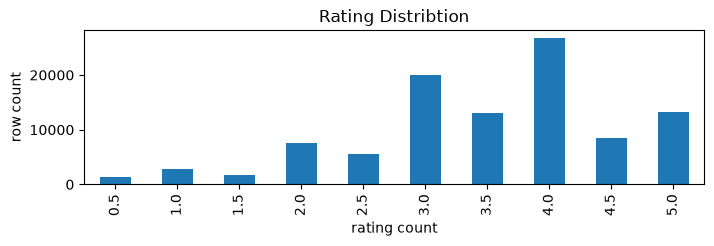

In [25]:
ratings_count.plot(kind="bar", figsize=(8,2))
plt.title("Rating Distribtion")
plt.xlabel("rating count")
plt.ylabel("row count")
plt.show()

- 어떤 평점이 가장 높은가?
- 왜곡 형태는 어떤가?
- 낮은 평점과 높은 평점들 중 어느 쪽이 많은가?

#### 사용자별 평점 개수

In [27]:
user_rating_count = ratings.groupby("userId").size().reset_index(name="user_rating_count")
print(user_rating_count)

     userId  user_rating_count
0         1                232
1         2                 29
2         3                 39
3         4                216
4         5                 44
..      ...                ...
605     606               1115
606     607                187
607     608                831
608     609                 37
609     610               1302

[610 rows x 2 columns]


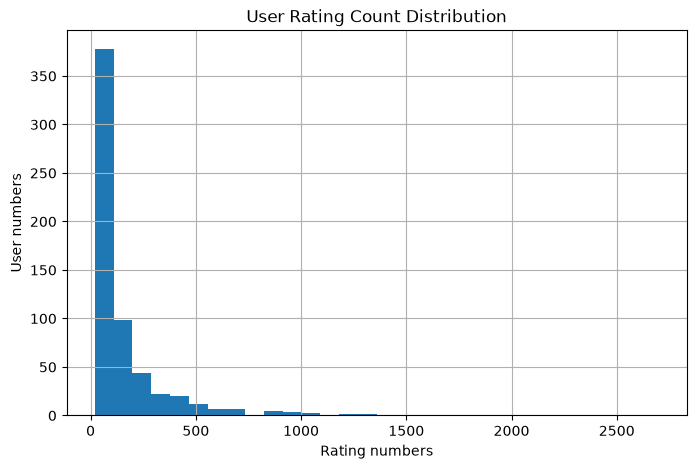

In [29]:
# 분포 확인
user_rating_count["user_rating_count"].hist(bins=30, figsize=(8,5))
plt.title("User Rating Count Distribution")
plt.xlabel("Rating numbers")
plt.ylabel("User numbers")
plt.show()

💥 평점 이력이 많은 사용자는 취향을 파악하기 쉬움

#### 영화별 평점 개수 Feature 생성

In [35]:
movie_rating_count = (ratings.groupby("movieId").size().reset_index(name="movie_rating_count"))
print(movie_rating_count)

      movieId  movie_rating_count
0           1                 215
1           2                 110
2           3                  52
3           4                   7
4           5                  49
...       ...                 ...
9719   193581                   1
9720   193583                   1
9721   193585                   1
9722   193587                   1
9723   193609                   1

[9724 rows x 2 columns]


In [36]:
# 영화별 평점 개수 + 영화 병합
movie_rating_count = movies.merge(movie_rating_count, on="movieId")
print(movie_rating_count)

      movieId                                      title  \
0           1                           Toy Story (1995)   
1           2                             Jumanji (1995)   
2           3                    Grumpier Old Men (1995)   
3           4                   Waiting to Exhale (1995)   
4           5         Father of the Bride Part II (1995)   
...       ...                                        ...   
9719   193581  Black Butler: Book of the Atlantic (2017)   
9720   193583               No Game No Life: Zero (2017)   
9721   193585                               Flint (2017)   
9722   193587        Bungo Stray Dogs: Dead Apple (2018)   
9723   193609        Andrew Dice Clay: Dice Rules (1991)   

                                           genres  movie_rating_count  
0     Adventure|Animation|Children|Comedy|Fantasy                 215  
1                      Adventure|Children|Fantasy                 110  
2                                  Comedy|Romance              

In [37]:
# 평점 개수를 기준으로 인기 영화 추천
popular_movies = movie_rating_count.sort_values("movie_rating_count", ascending=False)
print(popular_movies.head())

      movieId                             title                       genres  \
314       356               Forrest Gump (1994)     Comedy|Drama|Romance|War   
277       318  Shawshank Redemption, The (1994)                  Crime|Drama   
257       296               Pulp Fiction (1994)  Comedy|Crime|Drama|Thriller   
510       593  Silence of the Lambs, The (1991)        Crime|Horror|Thriller   
1938     2571                Matrix, The (1999)       Action|Sci-Fi|Thriller   

      movie_rating_count  
314                  329  
277                  317  
257                  307  
510                  279  
1938                 278  


💥 평점 개수가 높다는 것은 사용자가 많이 본 영화

    => 평점 개수만으로는 추천의 근거가 부족
    => 평균 평점 Feature을 추가적으로 생성

#### 영화별 평균 평점 Feature 생성

In [40]:
movie_rating_mean = (ratings.groupby("movieId")["rating"].mean().reset_index(name = "movie_rating_mean"))
print(movie_rating_mean)

      movieId  movie_rating_mean
0           1           3.920930
1           2           3.431818
2           3           3.259615
3           4           2.357143
4           5           3.071429
...       ...                ...
9719   193581           4.000000
9720   193583           3.500000
9721   193585           3.500000
9722   193587           3.500000
9723   193609           4.000000

[9724 rows x 2 columns]


In [43]:
movie_stats = movie_rating_count.merge(movie_rating_mean, on="movieId")
print(movie_stats.head())

   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  movie_rating_count  \
0  Adventure|Animation|Children|Comedy|Fantasy                 215   
1                   Adventure|Children|Fantasy                 110   
2                               Comedy|Romance                  52   
3                         Comedy|Drama|Romance                   7   
4                                       Comedy                  49   

   movie_rating_mean  
0           3.920930  
1           3.431818  
2           3.259615  
3           2.357143  
4           3.071429  
